### Coding Question: Image Classification Neural Network

Using the dataset provided below, design and implement a **Neural Network for multi-class image classification**.

**Dataset:** [Nepali Numbers and Letters Dataset](https://github.com/ShaileshAdhikari/nepali-text-classification/blob/main/images.rar)

Your implementation should include:

1. **Data Preparation**

   * Load, preprocess, resize, normalize, and split the dataset into train/validation/test sets.

2. **Neural Network**

3. **Hyperparameter Tuning**

4. **Evaluation**
   Evaluate the final model using:

   * Accuracy
   * Precision
   * Recall
   * F1-score
   * Macro/Weighted F1
   * Confusion Matrix

5. **Performance Analysis**

**Deliverable:** Complete, reproducible code with a final report comparing the experimented configurations and their performance.


In [71]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from PIL import Image

import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## Set random seeds

In [72]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## Inspect the dataset first

In [73]:
DATA_DIR = Path("images")
ARCHIVE_PATH = Path("images.rar")

print("Dataset directory exists:", DATA_DIR.is_dir())
print("Dataset archive exists:", ARCHIVE_PATH.is_file())

Dataset directory exists: True
Dataset archive exists: True


## Discover class folders

In [74]:
import subprocess

if DATA_DIR.is_dir():
    class_names = sorted(path.name for path in DATA_DIR.iterdir() if path.is_dir())
elif ARCHIVE_PATH.is_file():
    files = subprocess.check_output(
        ["bsdtar", "-tf", str(ARCHIVE_PATH)], text=True
    ).splitlines()
    class_names = sorted({
        path.split("/")[1]
        for path in files
        if path.startswith("images/") and len(path.split("/")) > 2
    })
else:
    class_names = []

print("Number of classes:", len(class_names))
for i, name in enumerate(class_names):
    print(i, "->", name)

Number of classes: 12
0 -> 0
1 -> 1
2 -> 2
3 -> 3
4 -> 4
5 -> 5
6 -> 6
7 -> 7
8 -> 8
9 -> 9
10 -> ba
11 -> pa


## Count images in every class

In [75]:
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}

class_counts = {}

for class_dir in class_dirs:
    count = sum(
        1 for file in class_dir.rglob("*")
        if file.suffix.lower() in image_extensions
    )
    
    class_counts[class_dir.name] = count

class_counts_df = pd.DataFrame(
    list(class_counts.items()),
    columns=["class", "image_count"]
)

class_counts_df.head()

,class,image_count


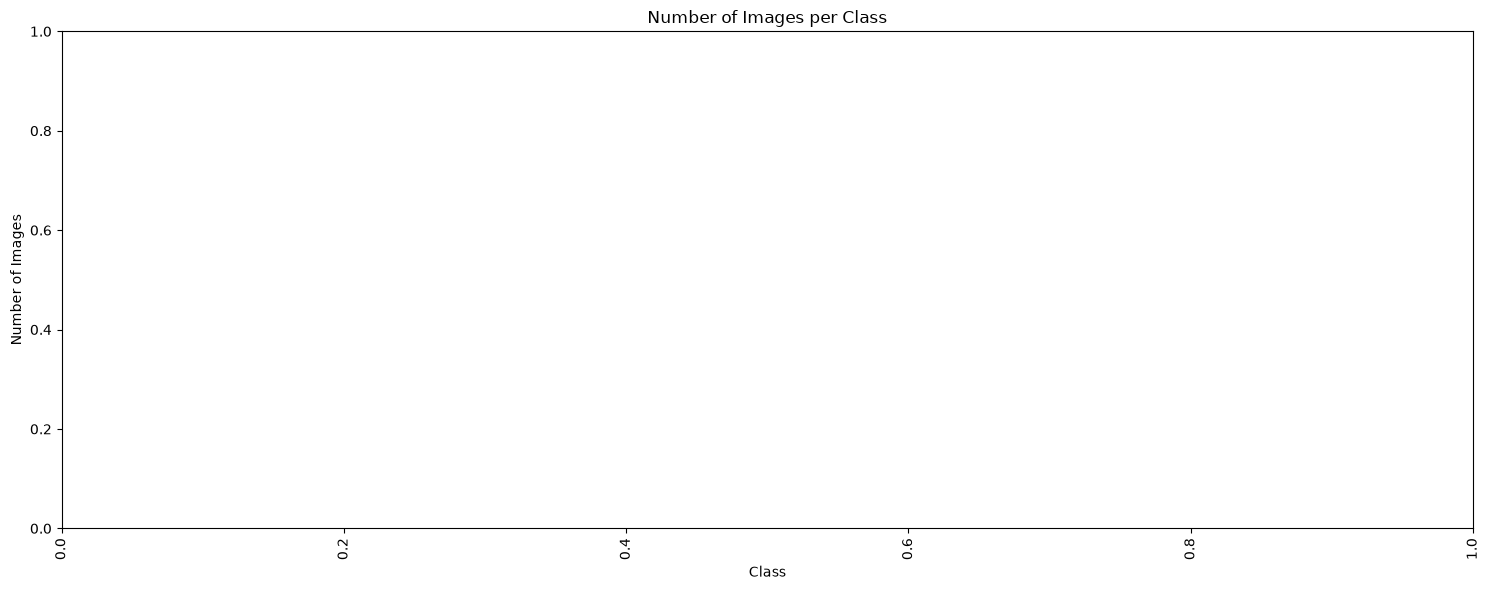

In [76]:
plt.figure(figsize=(15, 6))

sns.barplot(
    data=class_counts_df,
    x="class",
    y="image_count"
)

plt.xticks(rotation=90)
plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

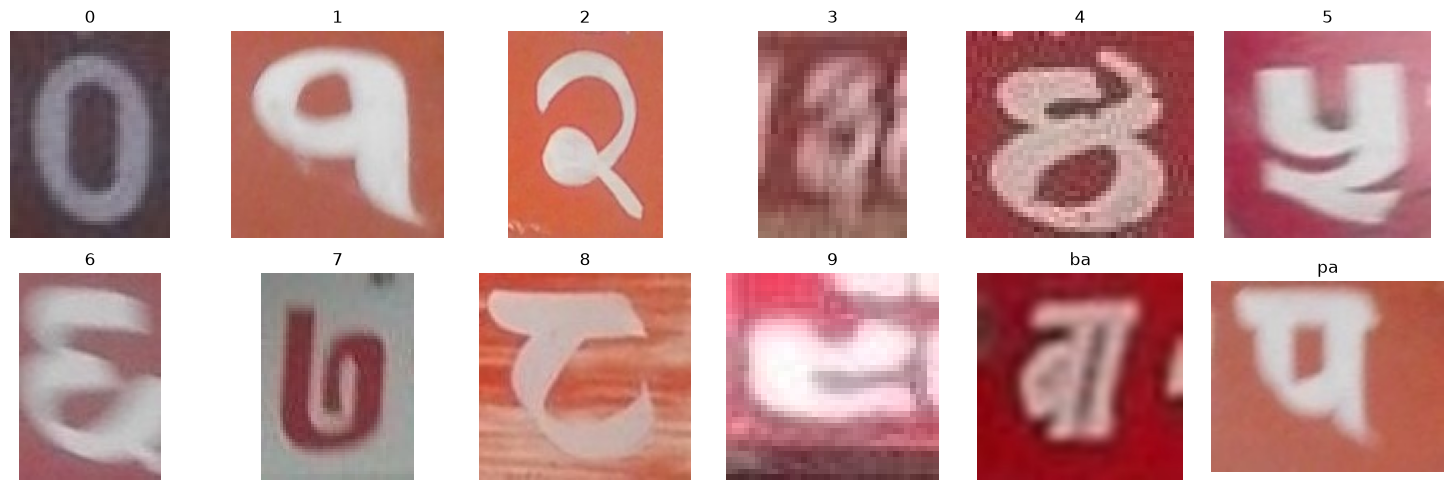

In [77]:
sample_files = [
    next(
        file for file in (DATA_DIR / name).rglob("*")
        if file.suffix.lower() in image_extensions
    )
    for name in class_names
]

fig, axes = plt.subplots(2, 6, figsize=(15, 5))

for axis, file in zip(axes.flat, sample_files):
    axis.imshow(Image.open(file))
    axis.set_title(file.parent.name)
    axis.axis("off")

plt.tight_layout()
plt.show()

## Create image dataframe

In [ ]:
image_paths = []
labels = []

class_to_index = {
    name: index
    for index, name in enumerate(class_names)
}

for class_name in class_names:
    for image_path in (DATA_DIR / class_name).rglob("*"):
        if image_path.suffix.lower() in image_extensions:
            image_paths.append(str(image_path))
            labels.append(class_to_index[class_name])

df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels,
})
df["class_name"] = df["label"].map(
    {index: name for name, index in class_to_index.items()}
)

print("Total images:", len(df))
df.head()

Total images: 0


,image_path,label,class_name


## Check for corrupted images

In [79]:
def check_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False


df["valid"] = df["image_path"].apply(check_image)

print(df["valid"].value_counts())

Series([], Name: count, dtype: int64)


In [82]:
if "valid" in df.columns:
    valid_mask = df["valid"].to_numpy(dtype=bool)
    df = df.loc[valid_mask].drop(columns="valid", errors="ignore")

print("Valid images:", len(df))

Valid images: 0
